In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

# Read data

In [3]:
vanilla = pd.read_csv('compas-mpa-bin-wout-agg-vanilla_lr-100.csv', index_col=0)
zhang = pd.read_csv('compas-mpa-bin-wout-agg-mult_adv-100.csv', index_col=0)

In [4]:
vanilla

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FP_g0,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.7852,0.7852,0.6783,0.8937,0.8882,0.8270,1121.0000,95.0000,...,10.0000,97.0000,14.0000,860.0000,95.0000,263.0000,212.0000,0.7858,0.7778,0.6506
1,SkVanillaLR,29,0.7769,0.7769,0.6696,0.8889,0.8568,0.7550,1152.0000,95.0000,...,6.0000,95.0000,13.0000,847.0000,100.0000,282.0000,211.0000,0.7675,0.7358,0.5863
2,SkVanillaLR,42,0.7723,0.7723,0.6590,0.8885,0.8698,0.7861,1145.0000,104.0000,...,11.0000,112.0000,10.0000,853.0000,105.0000,265.0000,202.0000,0.7784,0.7523,0.6197
3,SkVanillaLR,55,0.7820,0.7820,0.6793,0.8763,0.8401,0.7227,1131.0000,88.0000,...,13.0000,100.0000,19.0000,838.0000,85.0000,274.0000,215.0000,0.7758,0.7469,0.5914
4,SkVanillaLR,73,0.7709,0.7709,0.6620,0.8847,0.8832,0.8373,1131.0000,140.0000,...,10.0000,97.0000,16.0000,830.0000,143.0000,246.0000,204.0000,0.7629,0.7576,0.6682


In [5]:
zhang

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a1_TN_g0,a1_FP_g0,...,a2_FN_g0,a2_TP_g0,a2_TN_g1,a2_FP_g1,a2_FN_g1,a2_TP_g1,wc_spd,wc_aod,wc_eod,last_cosine_similarity
0,MultAdvBin4DP,13,0.7311,0.7311,0.6441,0.8551,0.8204,0.8095,1042.0000,144.0000,...,85.0000,25.0000,725.0000,208.0000,236.0000,225.0000,0.5939,0.5546,0.4636,0.2524
1,MultAdvBin4DP,29,0.7197,0.7197,0.6016,0.8456,0.8231,0.8080,1107.0000,117.0000,...,81.0000,25.0000,777.0000,146.0000,315.0000,160.0000,0.7065,0.7150,0.6937,0.1732
2,MultAdvBin4DP,42,0.7188,0.7188,0.5973,0.8455,0.7937,0.7455,1103.0000,119.0000,...,86.0000,33.0000,769.0000,167.0000,308.0000,146.0000,0.6857,0.6780,0.6612,0.2674
3,MultAdvBin4DP,55,0.7169,0.7169,0.6196,0.9400,0.9126,0.9462,1042.0000,142.0000,...,88.0000,29.0000,708.0000,190.0000,289.0000,194.0000,0.7255,0.7947,0.7992,0.1265
4,MultAdvBin4DP,73,0.7211,0.7211,0.6241,0.9138,0.8919,0.8920,1056.0000,179.0000,...,84.0000,26.0000,719.0000,235.0000,244.0000,199.0000,0.6441,0.6387,0.6130,0.1489
5,MultAdvBin4EqOdds,13,0.6979,0.6979,0.6287,0.7504,0.7320,0.7489,996.0000,190.0000,...,83.0000,27.0000,636.0000,297.0000,207.0000,254.0000,0.4080,0.3930,0.3462,0.2565
6,MultAdvBin4EqOdds,29,0.7003,0.7003,0.6220,0.7268,0.7038,0.6953,1046.0000,178.0000,...,86.0000,20.0000,656.0000,267.0000,236.0000,239.0000,0.3984,0.3922,0.3508,0.2336
7,MultAdvBin4EqOdds,42,0.6776,0.6776,0.6022,0.6872,0.6629,0.6676,1019.0000,203.0000,...,88.0000,31.0000,611.0000,325.0000,229.0000,225.0000,0.3223,0.3299,0.3380,0.5552
8,MultAdvBin4EqOdds,55,0.6941,0.6941,0.6182,0.8069,0.8100,0.8582,1004.0000,180.0000,...,90.0000,27.0000,635.0000,263.0000,248.0000,235.0000,0.5175,0.5286,0.5368,0.1135
9,MultAdvBin4EqOdds,73,0.6757,0.6757,0.5970,0.6933,0.6753,0.6788,1019.0000,216.0000,...,90.0000,20.0000,611.0000,343.0000,216.0000,227.0000,0.2841,0.2600,0.2105,0.1355


In [6]:
zhang[["model_name", "cv_seed", "last_cosine_similarity"]]

,model_name,cv_seed,last_cosine_similarity
0,MultAdvBin4DP,13,0.2524
1,MultAdvBin4DP,29,0.1732
2,MultAdvBin4DP,42,0.2674
3,MultAdvBin4DP,55,0.1265
4,MultAdvBin4DP,73,0.1489
5,MultAdvBin4EqOdds,13,0.2565
6,MultAdvBin4EqOdds,29,0.2336
7,MultAdvBin4EqOdds,42,0.5552
8,MultAdvBin4EqOdds,55,0.1135
9,MultAdvBin4EqOdds,73,0.1355


# Predictive performance

## Acc mean and std

In [6]:
vanilla_acc = vanilla.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([vanilla_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,SkVanillaLR,0.7775,0.0061
1,MultAdvBin4DP,0.7215,0.0056
2,MultAdvBin4EqOdds,0.6891,0.0116
3,MultAdvBin4EqOpp,0.7416,0.0057


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['SkVanillaLR', 'MultAdvBin4DP', 'MultAdvBin4EqOdds', 'MultAdvBin4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,SkVanillaLR,0.7775,0.0061
1,MultAdvBin4DP,0.7215,0.0056
2,MultAdvBin4EqOdds,0.6891,0.0116
3,MultAdvBin4EqOpp,0.7416,0.0057


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

0.7775 $\pm$ 0.0061
0.7215 $\pm$ 0.0056
0.6891 $\pm$ 0.0116
0.7416 $\pm$ 0.0057


## Micro-f1 mean and std

In [11]:
vanilla_micro = vanilla.groupby(['model_name'])['f1-micro'].agg([mean, stdev])
zhang_micro = zhang.groupby(['model_name'])['f1-micro'].agg([mean, stdev])

In [12]:
micro = pd.concat([vanilla_micro, zhang_micro])
micro = micro.reset_index()
micro = micro.rename(columns={'index': 'model_name'})
micro

,model_name,mean,stdev
0,SkVanillaLR,0.7775,0.0061
1,MultAdvBin4DP,0.7215,0.0056
2,MultAdvBin4EqOdds,0.6891,0.0116
3,MultAdvBin4EqOpp,0.7416,0.0057


In [13]:
micro['model_name'] = names
micro

,model_name,mean,stdev
0,SkVanillaLR,0.7775,0.0061
1,MultAdvBin4DP,0.7215,0.0056
2,MultAdvBin4EqOdds,0.6891,0.0116
3,MultAdvBin4EqOpp,0.7416,0.0057


In [14]:
print((micro['mean'].round(4).astype(str) + ' $\pm$ ' + micro['stdev'].round(4).astype(str)).to_string(index=False))

0.7775 $\pm$ 0.0061
0.7215 $\pm$ 0.0056
0.6891 $\pm$ 0.0116
0.7416 $\pm$ 0.0057


## Macro-f1 mean and std

In [15]:
vanilla_macro = vanilla.groupby(['model_name'])['f1-macro'].agg([mean, stdev])
zhang_macro = zhang.groupby(['model_name'])['f1-macro'].agg([mean, stdev])

In [16]:
macro = pd.concat([vanilla_macro, zhang_macro])
macro = macro.reset_index()
macro = macro.rename(columns={'index': 'model_name'})
macro

,model_name,mean,stdev
0,SkVanillaLR,0.6696,0.0092
1,MultAdvBin4DP,0.6173,0.0188
2,MultAdvBin4EqOdds,0.6136,0.0134
3,MultAdvBin4EqOpp,0.6031,0.0153


In [17]:
macro['model_name'] = names
macro

,model_name,mean,stdev
0,SkVanillaLR,0.6696,0.0092
1,MultAdvBin4DP,0.6173,0.0188
2,MultAdvBin4EqOdds,0.6136,0.0134
3,MultAdvBin4EqOpp,0.6031,0.0153


In [18]:
print((macro['mean'].round(4).astype(str) + ' $\pm$ ' + macro['stdev'].round(4).astype(str)).to_string(index=False))

0.6696 $\pm$ 0.0092
0.6173 $\pm$ 0.0188
0.6136 $\pm$ 0.0134
0.6031 $\pm$ 0.0153


# Group fairness for first protected attribute

## DP mean and std

In [19]:
vanilla_dp = vanilla.groupby(['model_name'])['a1_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a1_dp'].agg([mean, stdev])

In [20]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8864,0.0065
1,MultAdvBin4DP,0.8800,0.0440
2,MultAdvBin4EqOdds,0.7329,0.0487
3,MultAdvBin4EqOpp,0.9043,0.0158


In [21]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8864 $\pm$ 0.0065
   0.88 $\pm$ 0.044
0.7329 $\pm$ 0.0487
0.9043 $\pm$ 0.0158


## DEqOdds mean and std

In [22]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a1_deqodds'].agg([mean, stdev])

In [23]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.8676,0.0197
1,MultAdvBin4DP,0.8484,0.0511
2,MultAdvBin4EqOdds,0.7168,0.0585
3,MultAdvBin4EqOpp,0.8999,0.0239


In [24]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8676 $\pm$ 0.0197
0.8484 $\pm$ 0.0511
0.7168 $\pm$ 0.0585
0.8999 $\pm$ 0.0239


## DEqOpp mean and std

In [25]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a1_deqopp'].agg([mean, stdev])

In [26]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.7856,0.0481
1,MultAdvBin4DP,0.8402,0.0789
2,MultAdvBin4EqOdds,0.7298,0.0783
3,MultAdvBin4EqOpp,0.8613,0.0511


In [27]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.7856 $\pm$ 0.0481
0.8402 $\pm$ 0.0789
0.7298 $\pm$ 0.0783
0.8613 $\pm$ 0.0511


# Group fairness for second protected attribute

## DP mean and std

In [28]:
vanilla_dp = vanilla.groupby(['model_name'])['a2_dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['a2_dp'].agg([mean, stdev])

In [29]:
dp = pd.concat([vanilla_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,SkVanillaLR,0.8125,0.0141
1,MultAdvBin4DP,0.8194,0.0544
2,MultAdvBin4EqOdds,0.7101,0.0262
3,MultAdvBin4EqOpp,0.9203,0.0298


In [30]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8125 $\pm$ 0.0141
0.8194 $\pm$ 0.0544
0.7101 $\pm$ 0.0262
0.9203 $\pm$ 0.0298


## DEqOdds mean and std

In [31]:
vanilla_deqodds = vanilla.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['a2_deqodds'].agg([mean, stdev])

In [32]:
deqodds = pd.concat([vanilla_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,SkVanillaLR,0.7956,0.0187
1,MultAdvBin4DP,0.8504,0.0615
2,MultAdvBin4EqOdds,0.7305,0.0285
3,MultAdvBin4EqOpp,0.9441,0.0298


In [33]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.7956 $\pm$ 0.0187
0.8504 $\pm$ 0.0615
0.7305 $\pm$ 0.0285
0.9441 $\pm$ 0.0298


## DEqOpp mean and std

In [34]:
vanilla_deqopp = vanilla.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['a2_deqopp'].agg([mean, stdev])

In [35]:
deqopp = pd.concat([vanilla_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,SkVanillaLR,0.6860,0.0254
1,MultAdvBin4DP,0.8455,0.0862
2,MultAdvBin4EqOdds,0.7117,0.0408
3,MultAdvBin4EqOpp,0.9320,0.0392


In [36]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

 0.686 $\pm$ 0.0254
0.8455 $\pm$ 0.0862
0.7117 $\pm$ 0.0408
 0.932 $\pm$ 0.0392


# Intersectional Fairness

## WCSPD mean and std

In [37]:
vanilla_wcspd = vanilla.groupby(['model_name'])['wc_spd'].agg([mean, stdev])
zhang_wcspd = zhang.groupby(['model_name'])['wc_spd'].agg([mean, stdev])

In [38]:
wcspd = pd.concat([vanilla_wcspd, zhang_wcspd])
wcspd = wcspd.reset_index()
wcspd = wcspd.rename(columns={'index': 'model_name'})
wcspd['model_name'] = names
wcspd

,model_name,mean,stdev
0,SkVanillaLR,0.7741,0.0091
1,MultAdvBin4DP,0.6711,0.0527
2,MultAdvBin4EqOdds,0.3861,0.0900
3,MultAdvBin4EqOpp,0.8616,0.0242


In [39]:
print((wcspd['mean'].round(4).astype(str) + ' $\pm$ ' + wcspd['stdev'].round(4).astype(str)).to_string(index=False))

0.7741 $\pm$ 0.0091
0.6711 $\pm$ 0.0527
  0.3861 $\pm$ 0.09
0.8616 $\pm$ 0.0242


## WCAOD mean and std

In [40]:
vanilla_wcaod = vanilla.groupby(['model_name'])['wc_aod'].agg([mean, stdev])
zhang_wcaod = zhang.groupby(['model_name'])['wc_aod'].agg([mean, stdev])

In [41]:
wcaod = pd.concat([vanilla_wcaod, zhang_wcaod])
wcaod = wcaod.reset_index()
wcaod = wcaod.rename(columns={'index': 'model_name'})
wcaod['model_name'] = names
wcaod

,model_name,mean,stdev
0,SkVanillaLR,0.7541,0.0155
1,MultAdvBin4DP,0.6762,0.0891
2,MultAdvBin4EqOdds,0.3807,0.0991
3,MultAdvBin4EqOpp,0.8698,0.0302


In [42]:
print((wcaod['mean'].round(4).astype(str) + ' $\pm$ ' + wcaod['stdev'].round(4).astype(str)).to_string(index=False))

0.7541 $\pm$ 0.0155
0.6762 $\pm$ 0.0891
0.3807 $\pm$ 0.0991
0.8698 $\pm$ 0.0302


## WCEOD mean and std

In [43]:
vanilla_wceod = vanilla.groupby(['model_name'])['wc_eod'].agg([mean, stdev])
zhang_wceod = zhang.groupby(['model_name'])['wc_eod'].agg([mean, stdev])

In [44]:
wceod = pd.concat([vanilla_wceod, zhang_wceod])
wceod = wceod.reset_index()
wceod = wceod.rename(columns={'index': 'model_name'})
wceod['model_name'] = names
wceod

,model_name,mean,stdev
0,SkVanillaLR,0.6232,0.0359
1,MultAdvBin4DP,0.6461,0.1228
2,MultAdvBin4EqOdds,0.3564,0.1165
3,MultAdvBin4EqOpp,0.8207,0.0550


In [45]:
print((wceod['mean'].round(4).astype(str) + ' $\pm$ ' + wceod['stdev'].round(4).astype(str)).to_string(index=False))

0.6232 $\pm$ 0.0359
0.6461 $\pm$ 0.1228
0.3564 $\pm$ 0.1165
 0.8207 $\pm$ 0.055


# T-test

In [46]:
vanilla_lr = vanilla
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [47]:
models = [
    vanilla_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [48]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [49]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

## for accuracies

In [50]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [51]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0000,-,-,-
MultAdvBin4EqOdds,0.0000,0.0030,-,-
MultAdvBin4EqOpp,0.0001,0.0002,0.0004,-


In [52]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-micro'], models[j]['f1-micro'])
        res_acc.iloc[i, j] = stat[1]

In [53]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0000,-,-,-
MultAdvBin4EqOdds,0.0000,0.0030,-,-
MultAdvBin4EqOpp,0.0001,0.0002,0.0004,-


In [54]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['f1-macro'], models[j]['f1-macro'])
        res_acc.iloc[i, j] = stat[1]

In [55]:
res_acc.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0015,-,-,-
MultAdvBin4EqOdds,0.0001,0.6765,-,-
MultAdvBin4EqOpp,0.0001,0.0031,0.1646,-


## for group fairness A1

In [56]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_dp'], models[j]['a1_dp'])
        res_dp.iloc[i, j] = stat[1]

In [57]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.7879,-,-,-
MultAdvBin4EqOdds,0.0028,0.0020,-,-
MultAdvBin4EqOpp,0.0784,0.3552,0.0023,-


In [58]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqodds'], models[j]['a1_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [59]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.5211,,,
MultAdvBin4EqOdds,0.0096,0.0042,,
MultAdvBin4EqOpp,0.0718,0.1562,0.0067,


In [60]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a1_deqopp'], models[j]['a1_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [61]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.3030,,,
MultAdvBin4EqOdds,0.3331,0.0150,,
MultAdvBin4EqOpp,0.0405,0.7083,0.0815,


## for group fairness A2

In [62]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_dp'], models[j]['a2_dp'])
        res_dp.iloc[i, j] = stat[1]

In [63]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.7866,-,-,-
MultAdvBin4EqOdds,0.0001,0.0076,-,-
MultAdvBin4EqOpp,0.0010,0.0049,0.0002,-


In [64]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqodds'], models[j]['a2_deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [65]:
res_deqodds.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.1349,,,
MultAdvBin4EqOdds,0.0019,0.0076,,
MultAdvBin4EqOpp,0.0006,0.0082,0.0001,


In [66]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['a2_deqopp'], models[j]['a2_deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [67]:
res_deqopp.T.fillna('')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,,,,
MultAdvBin4DP,0.0221,,,
MultAdvBin4EqOdds,0.3385,0.0120,,
MultAdvBin4EqOpp,0.0004,0.0245,0.0001,


## for intersectional fairness

In [68]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_spd'], models[j]['wc_spd'])
        res_dp.iloc[i, j] = stat[1]

In [69]:
res_dp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.0153,-,-,-
MultAdvBin4EqOdds,0.0006,0.0016,-,-
MultAdvBin4EqOpp,0.0021,0.0004,0.0004,-


In [70]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_aod'], models[j]['wc_aod'])
        res_deqodds.iloc[i, j] = stat[1]

In [71]:
res_deqodds.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.1641,-,-,-
MultAdvBin4EqOdds,0.0013,0.0015,-,-
MultAdvBin4EqOpp,0.0026,0.0079,0.0007,-


In [72]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['wc_eod'], models[j]['wc_eod'])
        res_deqopp.iloc[i, j] = stat[1]

In [73]:
res_deqopp.T.fillna('-')

,SkVanillaLR,MultAdvBin4DP,MultAdvBin4EqOdds,MultAdvBin4EqOpp
SkVanillaLR,-,-,-,-
MultAdvBin4DP,0.7522,-,-,-
MultAdvBin4EqOdds,0.0147,0.0040,-,-
MultAdvBin4EqOpp,0.0012,0.0480,0.0030,-


# Plotting

## Plotting Accuracies

In [74]:
model_names = vanilla['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [75]:
model_names

['SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'SkVanillaLR',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4DP',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOdds',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp',
 'MultAdvBin4EqOpp']

In [76]:
model_accs = vanilla['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26077/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


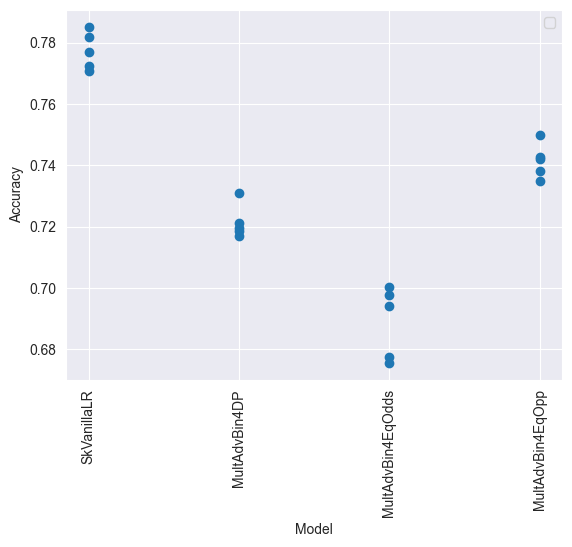

In [77]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [78]:
model_spd = vanilla['wc_spd'].to_list()+zhang['wc_spd'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26077/545090117.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


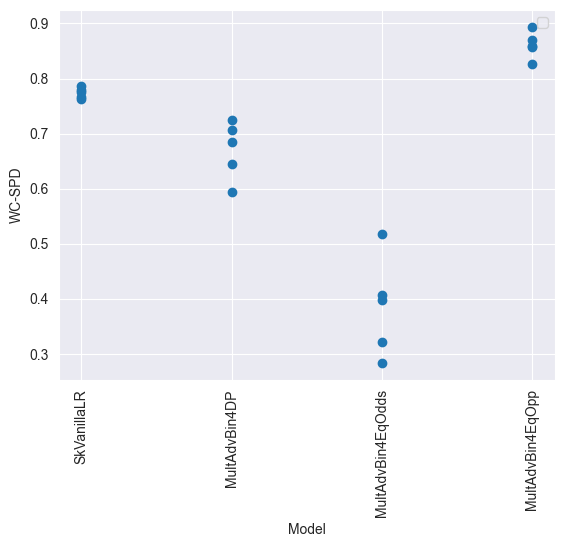

In [79]:
plt.plot()
plt.ylabel('WC-SPD')

plt.scatter(model_names, model_spd)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26077/1727290324.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


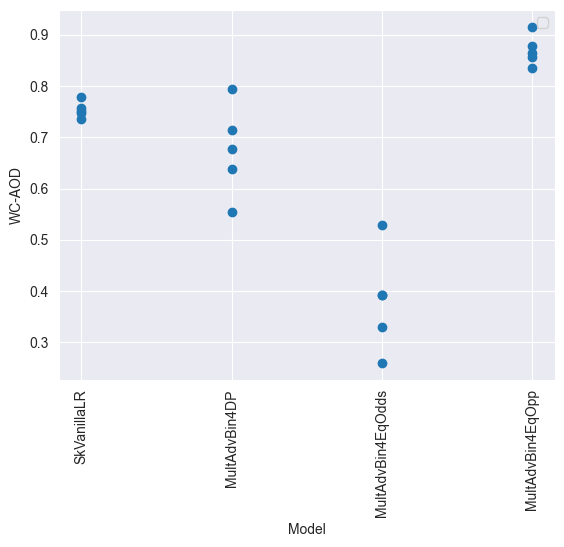

In [80]:
model_aod = vanilla['wc_aod'].to_list()+zhang['wc_aod'].to_list()
plt.plot()
plt.ylabel('WC-AOD')

plt.scatter(model_names, model_aod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_26077/2617305754.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


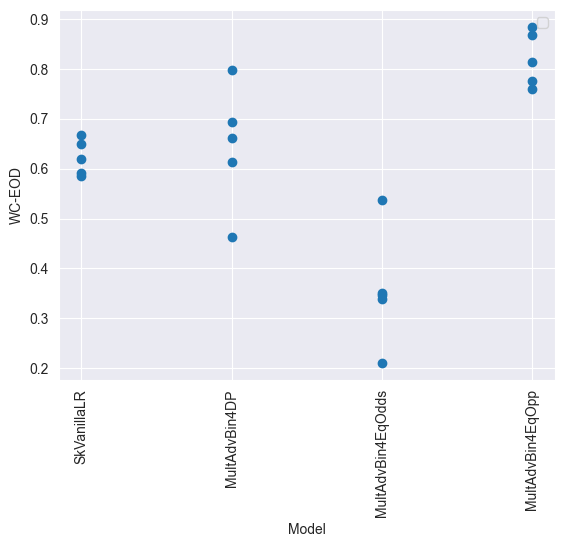

In [81]:
model_eod = vanilla['wc_eod'].to_list()+zhang['wc_eod'].to_list()
plt.plot()
plt.ylabel('WC-EOD')

plt.scatter(model_names, model_eod)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x WC-SPD

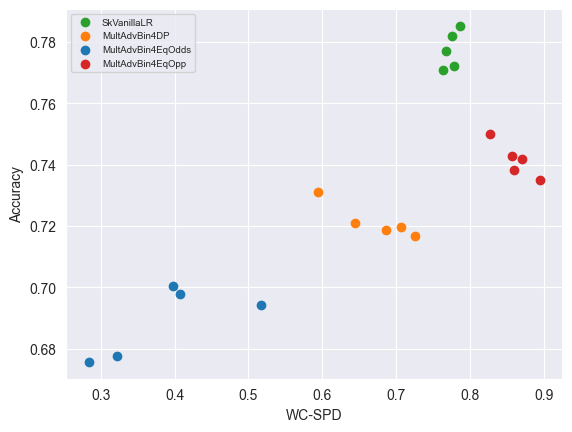

<Figure size 700x700 with 0 Axes>

In [82]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-SPD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_spd[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-AOD

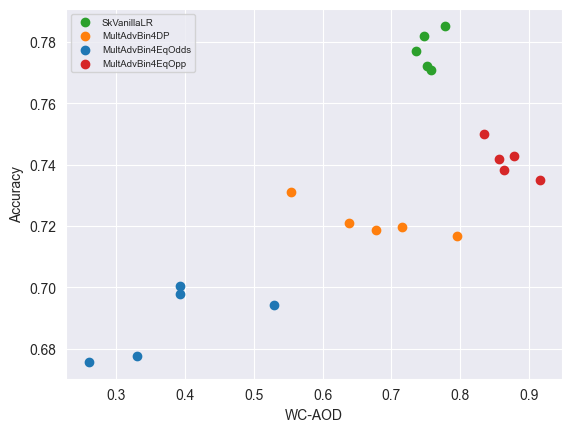

<Figure size 700x700 with 0 Axes>

In [83]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-AOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_aod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x WC-EOD

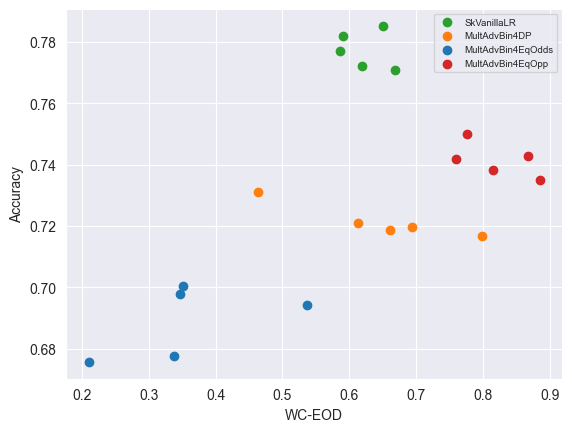

<Figure size 700x700 with 0 Axes>

In [84]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

# assign one color per model
unique_models = list(set(model_names))
cmap = plt.get_cmap('tab10')
color_dict = {
    model: cmap(i % 10)
    for i, model in enumerate(unique_models)
}

plt.xlabel('WC-EOD')
plt.ylabel('Accuracy')

seen = set()

for i, model_name in enumerate(model_names):
    label = model_name if model_name not in seen else None
    seen.add(model_name)
    plt.scatter(
        model_eod[i],
        model_accs[i],
        label=label,
        color=color_dict[model_name]
    )
plt.legend(fontsize='x-small')
plt.figure(figsize=(7,7))

plt.show()